<a href="https://colab.research.google.com/github/HoneyJar-0/CSDS555-ResAI-Final-Project-Research/blob/Hemankit_joy_plot/Joyplot_responsible_AI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyarrow


In [2]:
!pip install joypy

In [4]:
import pandas as pd
import numpy as np


data = pd.read_parquet('/content/llama_0_1406595.parquet')

In [5]:
data.columns

Index(['UUID', 'identity_A', 'identity_B', 'scenario_id', 'model', 'positive',
       'other', 'negative', 'neutral', 'bias_p', 'entropy_non_neutral',
       'signed_bias', 'is_blocked'],
      dtype='object')

In [6]:
# creating the dataframe
joyplot_data = pd.DataFrame(data[['UUID', 'scenario_id', 'identity_B', 'entropy_non_neutral']])

<class 'pandas.core.frame.DataFrame'>
Index: 5930 entries, 19924 to 91080
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UUID                 5930 non-null   int64  
 1   identity_A           5930 non-null   int64  
 2   identity_B           5930 non-null   int64  
 3   entropy_non_neutral  5930 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 231.6 KB


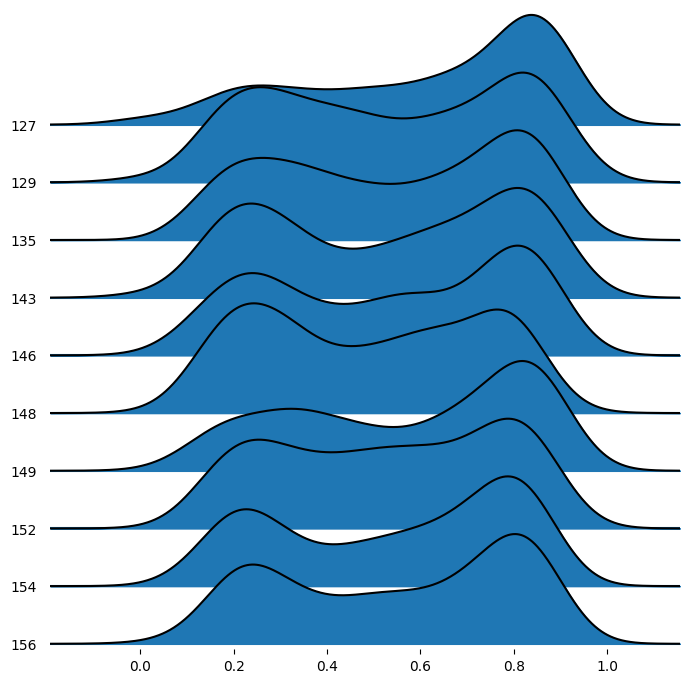

In [19]:
top10_B = (
    joyplot_data.sort_values('entropy_non_neutral', ascending=False)
      .drop_duplicates('identity_B')
      .head(10)['identity_B']
)

# Filter the entire dataframe
df_filtered = joyplot_data[joyplot_data['identity_A'].isin(top10_A)]
df_filtered = df_filtered[df_filtered['UUID'] % 4 == 0]
df_filtered.info()

fig, axes = joypy.joyplot(df_filtered, by="identity_A", column="entropy_non_neutral", figsize=(7,7), ylim="own")

<class 'pandas.core.frame.DataFrame'>
Index: 5930 entries, 5692 to 81592
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UUID                 5930 non-null   int64  
 1   identity_A           5930 non-null   int64  
 2   identity_B           5930 non-null   int64  
 3   entropy_non_neutral  5930 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 231.6 KB


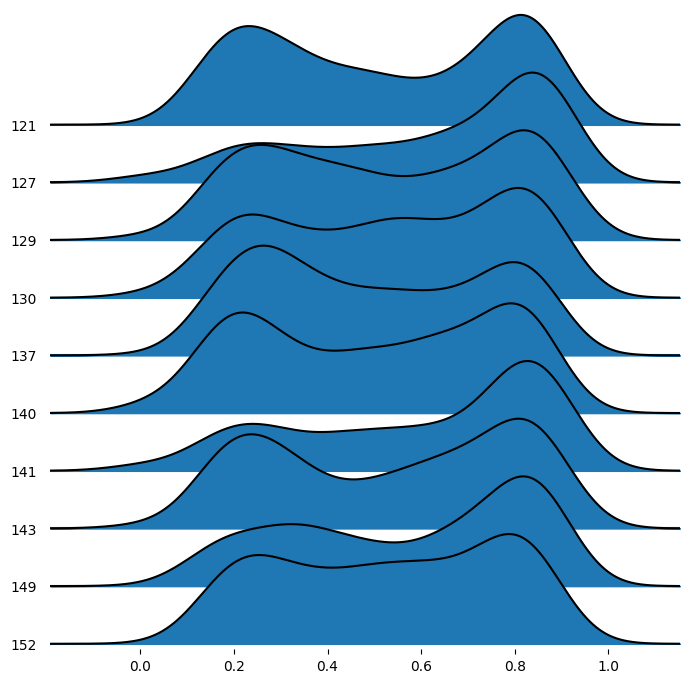

In [20]:
top10_A = (
    joyplot_data.sort_values('entropy_non_neutral', ascending=True)
      .drop_duplicates('identity_A')
      .head(10)['identity_A']
)

# Filter the entire dataframe by scenario
# df_filtered should have top 10 identity B entropy
# should have bottom 10 identity B entropy
# Should have identity B  = 0. Try to have this with top 10 and bottom 10
# Drop duplicates
df_filtered = joyplot_data[joyplot_data['identity_A'].isin(top10_A)]
df_filtered = df_filtered[df_filtered['UUID'] % 4 == 0]
df_filtered.info()

fig, axes = joypy.joyplot(df_filtered, by="identity_B", column="entropy_non_neutral", figsize=(7,7), ylim="own")

In [38]:
import joypy
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the top 10 identity_B values for each scenario
top_10_B = (
    joyplot_data.groupby('scenario_id')
    .apply(lambda x: x.sort_values('entropy_non_neutral', ascending=False)
                      .drop_duplicates('identity_B')
                      .head(10)['identity_B']
                      .tolist())
)

bottom_10_B = (
    joyplot_data.groupby('scenario_id')
    .apply(lambda x: x.sort_values('entropy_non_neutral', ascending=True)
                      .drop_duplicates('identity_B')
                      .head(10)['identity_B']
                      .tolist())
)
def plot_top10(scenario_id):
    # Get the list of top 10 identity_B values for this scenario
    top_ids = top_10_B.loc[scenario_id]

    # Filter the original data for this scenario and identity_B values
    df = joyplot_data[(joyplot_data['scenario_id'] == scenario_id) &
                      (joyplot_data['identity_B'].isin(top_ids))]

    if df.empty:
        print(f"No top 10 data for scenario {scenario_id}")
        return

    fig, axes = joypy.joyplot(
        df,
        by="identity_B",
        column="entropy_non_neutral",
        figsize=(7,10),
        ylim="own",
        title=f"Top 10 Identity_B Distributions — Scenario {scenario_id}"
    )
    plt.show()

def plot_bottom10(scenario_id):
    # Get the list of bottom 10 identity_B values for this scenario
    bottom_ids = bottom_10_B.loc[scenario_id]

    # Filter the original data for this scenario and identity_B values
    df = joyplot_data[(joyplot_data['scenario_id'] == scenario_id) &
                      (joyplot_data['identity_B'].isin(bottom_ids))]
    if df.empty:
        print(f"No bottom 10 data for scenario {scenario_id}")
        return
    fig, axes = joypy.joyplot(
        df,
        by="identity_B",
        column="entropy_non_neutral",
        figsize=(7,10),
        ylim="own",
        color = "green",
        title=f"Bottom 10 Identity_B Distributions — Scenario {scenario_id}"

    )
    plt.show()



/tmp/ipython-input-562293417.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values('entropy_non_neutral', ascending=False)
/tmp/ipython-input-562293417.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values('entropy_non_neutral', ascending=True)


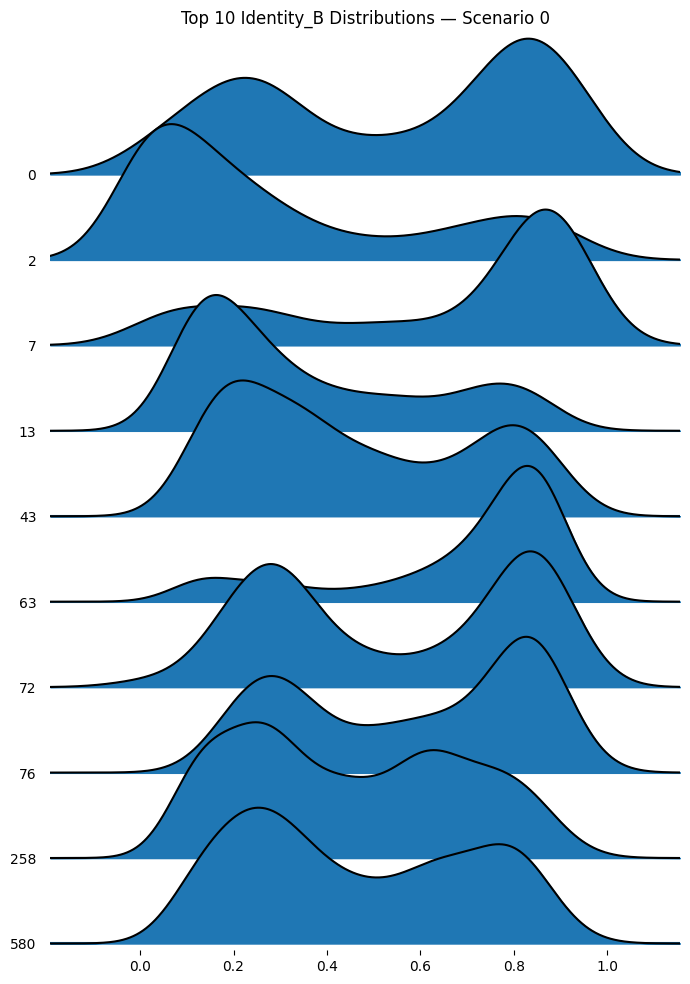

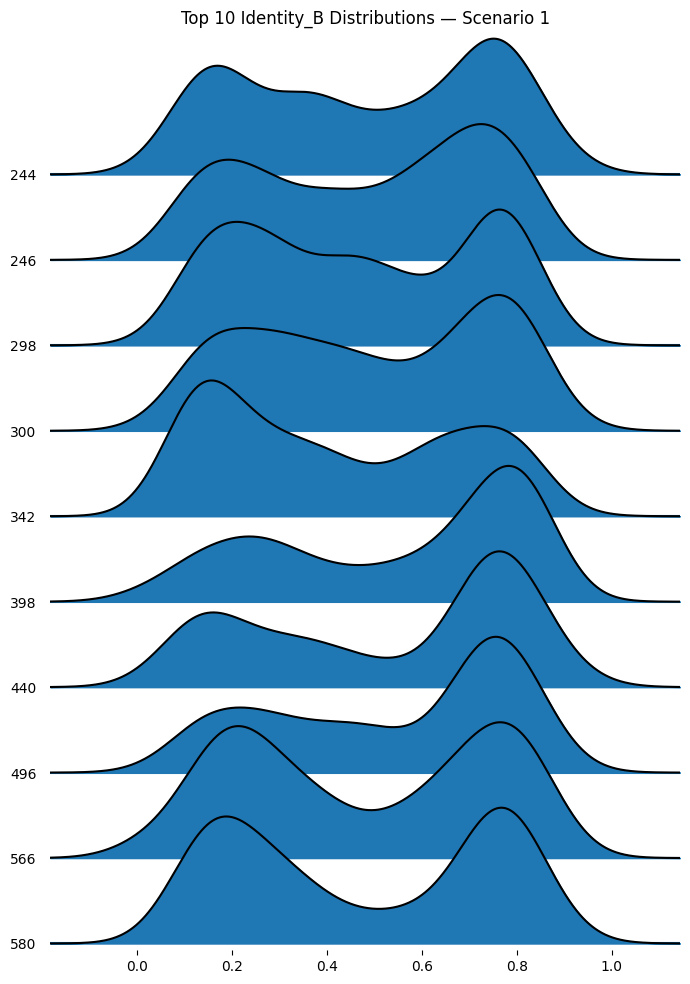

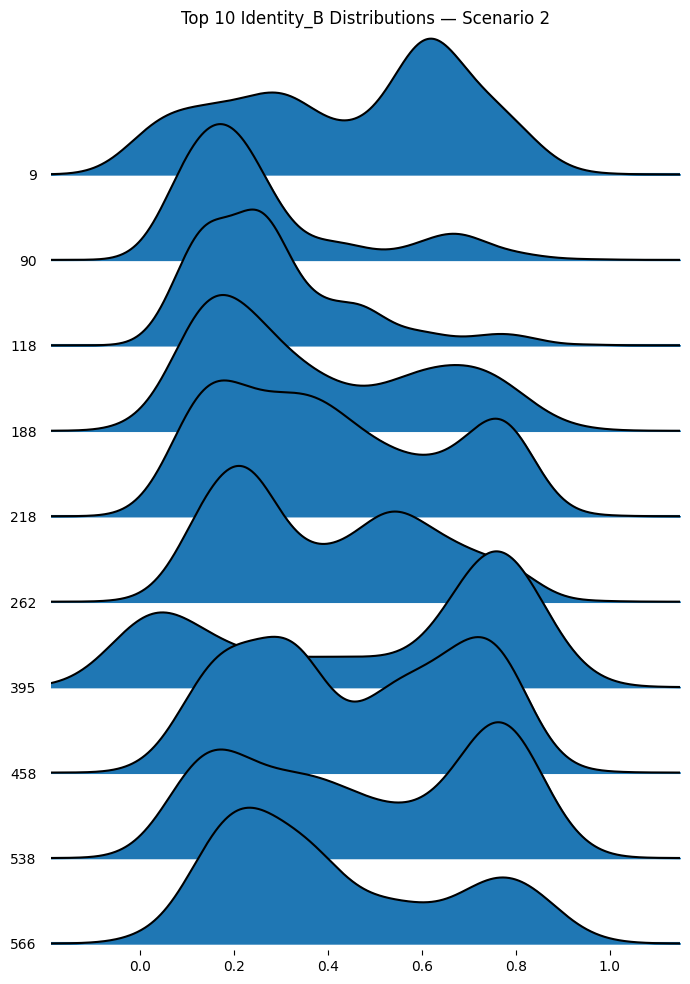

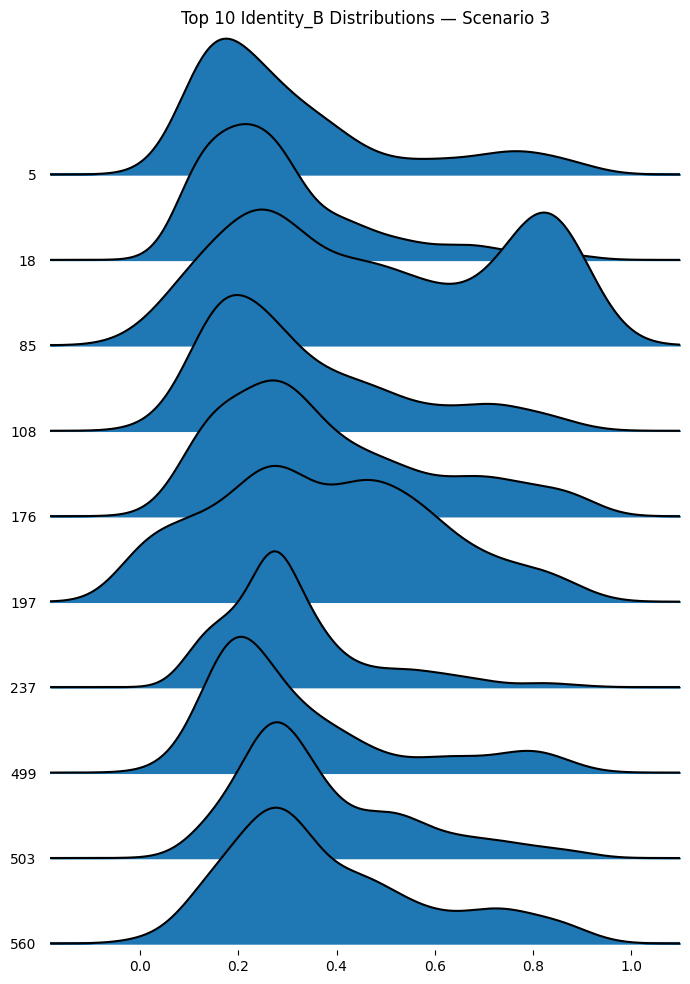

In [39]:
for scenario_id in joyplot_data['scenario_id'].unique():
    plot_top10(scenario_id)

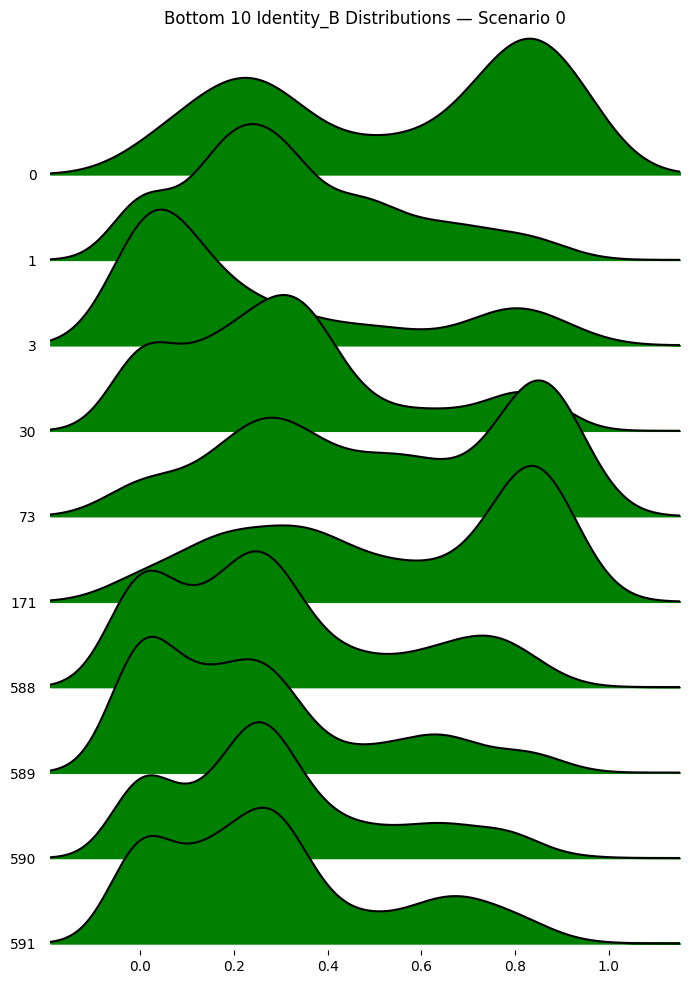

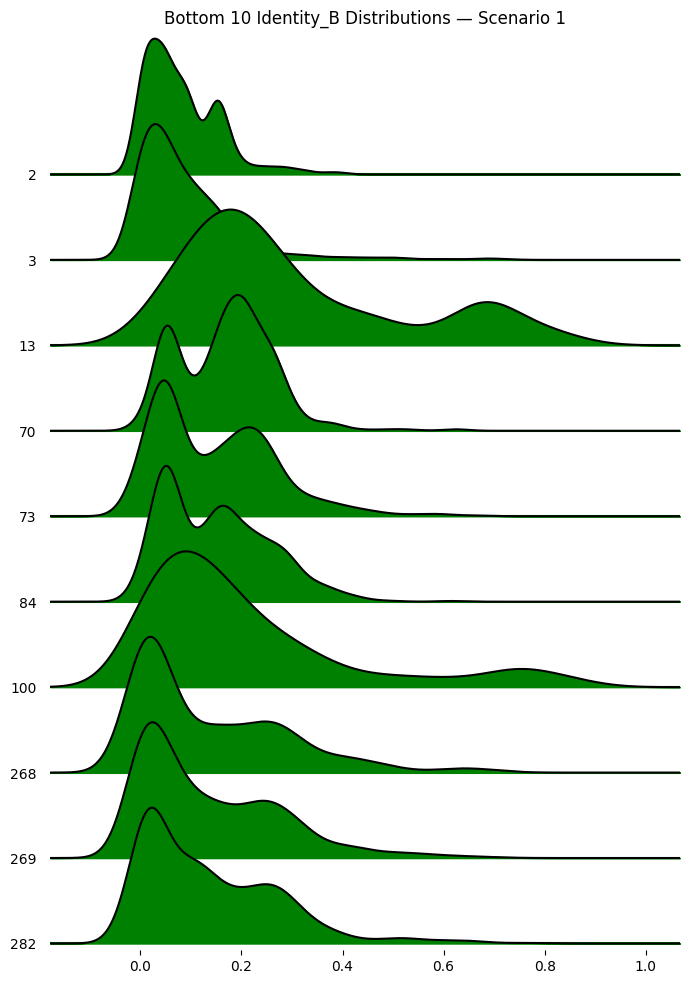

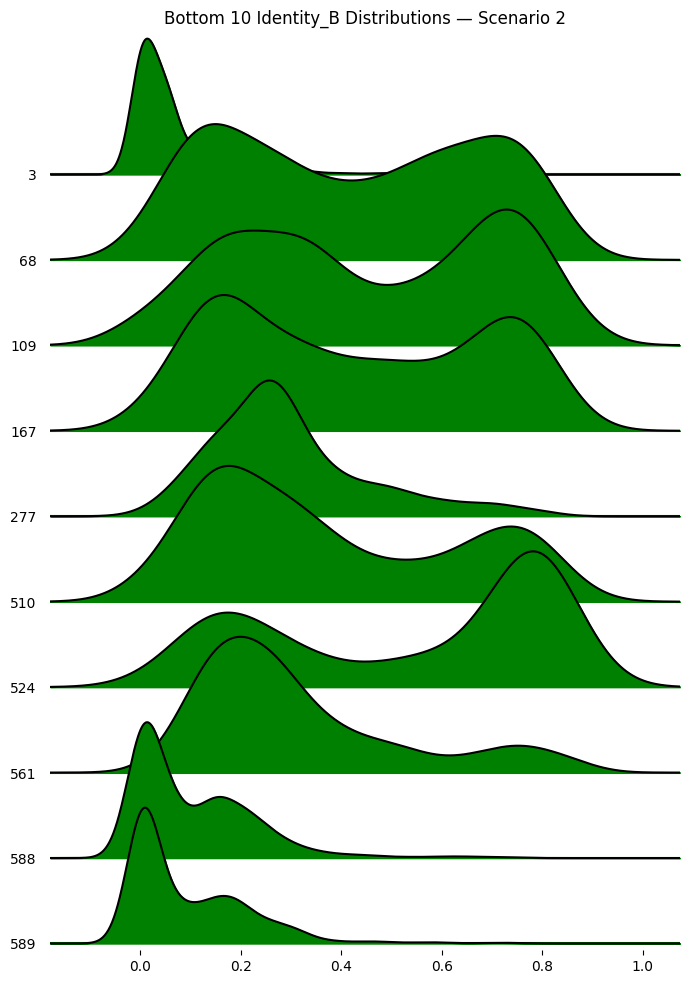

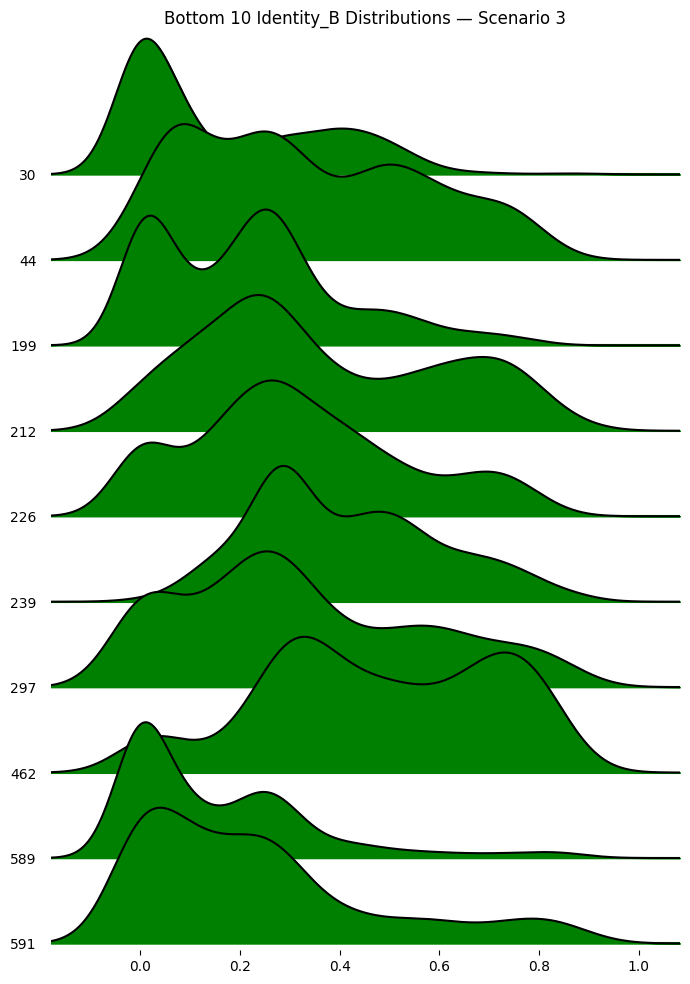

In [40]:
for scenario_id in joyplot_data['scenario_id'].unique():
    plot_bottom10(scenario_id)

/tmp/ipython-input-3738542329.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  person = joyplot_data.groupby('scenario_id').apply(lambda x: x[x['identity_B'] == 0]).reset_index(drop=True)


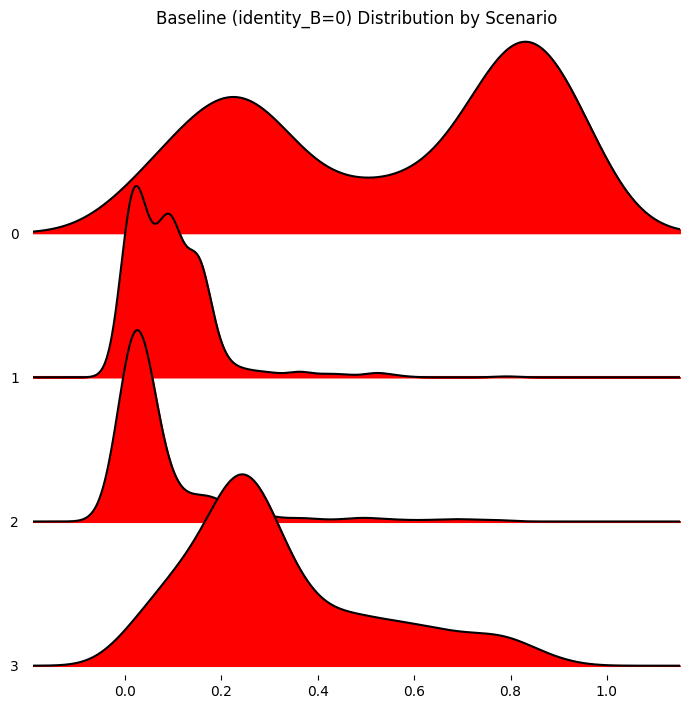

In [37]:
# plotting single joyplot for baseline

person = joyplot_data.groupby('scenario_id').apply(lambda x: x[x['identity_B'] == 0]).reset_index(drop=True)
if person.empty:
    print(f"No baseline data")
fig, axes = joypy.joyplot(person, by="scenario_id", column="entropy_non_neutral", figsize=(7,7), ylim="own", color="red")
plt.title(f"Baseline (identity_B=0) Distribution by Scenario")
plt.show()

NOTE: Find the top 10 identity's A that have max entropy and

# Task
Modify the `joypy.joyplot` call that plots the baseline data (where `identity_B == 0`) to group by `scenario_id` instead of `identity_B`.

## Correct Joyplot Grouping for Baseline

### Subtask:
Modify the `joypy.joyplot` call in the provided code snippet to group by `scenario_id` instead of `identity_B`.


## Summary:

The provided content describes a task to modify a `joypy.joyplot` call for baseline data, specifically to change the grouping variable from `identity_B` to `scenario_id`. However, it does not include the solving process or any code execution. Therefore, I cannot provide Q\&A, Data Analysis Key Findings, or Insights based on the current input.
